# Compare various IFS experiments at Cabauw

### First look at TKE scheme on and off

### Second look at dryMF on and off


In [1]:
import xarray as xr
import os
import dask
import h5netcdf
import scipy
import numpy as np
from datetime import timedelta
import datetime
import matplotlib.pyplot as plt
from matplotlib import ticker
from matplotlib.colors import TwoSlopeNorm
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker  
import pint
from pint import UnitRegistry
ureg = UnitRegistry()
import matplotlib.pylab as pylab
params = {'legend.fontsize': 'large',
         'axes.labelsize': 22,
         'axes.titlesize':'large',
         'xtick.labelsize':18,
         'ytick.labelsize':18,
         'figure.figsize':[10,7],
         'figure.titlesize':22}
pylab.rcParams.update(params)

import sys
sys.path.append(".")  # Ensures the current directory is in the Python path
sys.path.append("/home/paaa/python_scripts/")
import my_functions as mfun
from my_classes import DatasetProcessor


In [2]:
dir_in   = "/perm/paaa/IFS/cabauw"

exp_names = [
    ('ctrl'     , 'Cabauw_SPPoff_TKEoff' ,  'Control'),
    ('TKE'      , 'Cabauw_SPPoff_TKEon'  ,  'TKE'),
    ('dryMF'    , 'Cabauw_SPPoff_dryMFv1',  'dry MF'),
    ('ctrl_9km' , 'iq88_ctrl_9km'        ,  '9 km')
]
nemo_exp_names = [
    # ('SPP_ctrl',  'iq87_SPP_ctrl'  , 'SPP'       , 'grey'),
    # ('SPP_conv',  'iqgl_SPP_conv'  , 'SPP conv.' , 'red' ),
    # ('SPP_diff',  'iqhl_SPP_diff'  , 'SPP diff.' , 'blue'),
    ('SPP_all',     'iqpa_SPP_noIC'       , 'SPP all'   , 'grey'),
    ('SPP_conv',    'iqs0_SPP_noIC_conv'  , 'SPP conv'  , 'red'),
    ('SPP_diff',    'issq_SPP_noIC_turb'  , 'SPP turb'  , 'green'),
    ('SPP_rad',     'issr_SPP_noIC_rad'   , 'SPP rad'   , 'blue'),
]

lead_time = 24 # do you want to analayse FC day1 (leasd_time = 0) or FC day2 (leasd_time = 24) ? 
UTC_to_LT = +2 #hours from UTC
str_time = '2022-05-15'
end_time = '2022-05-21'
daytime  = [6,21]

col = ['#D04848','#6895D2','#F3B95F','#59981A']
sty = ['-','--',':']

#######################################
# Time limits
t0 = datetime.datetime.strptime(str_time, "%Y-%m-%d")
t1 = datetime.datetime.strptime(end_time, "%Y-%m-%d")

In [3]:
ctr_flx    = xr.open_mfdataset('/perm/paaa/IFS/netherlands/fc/itvc_ctrl_flxntend_z_t24.nc',
                               combine='by_coords')

ctr_flx_slab = ctr_flx.mean(('latitude', 'longitude'), keep_attrs=True)

ctr_flx_slab['uflx_conv'] = mfun.deacc_variable(ctr_flx_slab['uflx_conv'],restart=1)
ctr_flx_slab['uflx_diff'] = mfun.deacc_variable(ctr_flx_slab['uflx_diff'],restart=1)
ctr_flx_slab['uflx_dyn']  = mfun.deacc_variable(ctr_flx_slab['uflx_dyn'],restart=1)

In [4]:
srf_nemo_slab_dict = {}
srf_nemo_dict = {}

for exp, exp_longname, _,_ in nemo_exp_names:
    if exp == 'SPP_noIC':
        l_time = f't{lead_time}'
    else:
        # l_time = ''
        l_time = f't{lead_time}'
    processor_ensemble = DatasetProcessor(exp_longname, dir_in + '/eps_nemo',l_time,UTC_to_LT)
    srf_nemo_slab_dict[exp] = processor_ensemble.get_ds_srf_slab()
    srf_nemo_dict[exp]      = processor_ensemble.get_ds_srf()

srf_fc_slab_dict = {}
srf_fc_dict      = {}
z_fc_slab_dict   = {}
z_fc_dict        = {}

for exp, exp_longanme, label in exp_names:
    processor_fc = DatasetProcessor(exp_longanme, dir_in)
    srf_fc_slab_dict[exp] = processor_fc.get_ds_srf_slab()
    srf_fc_dict[exp]      = processor_fc.get_ds_srf()
    z_fc_slab_dict[exp]   = processor_fc.get_ds_z_slab()
    z_fc_dict[exp]        = processor_fc.get_ds_z()

    # z_fc_slab_dict[exp]['th'] = mfun.calc_th(z_fc_slab_dict[exp]['t'],z_fc_slab_dict[exp]['p'])
    # z_fc_slab_dict[exp]['thl'] = mfun.calc_thl(z_fc_slab_dict[exp]['th'],z_fc_slab_dict[exp]['clwc'],z_fc_slab_dict[exp]['p']) # is clwc same as ql ?


Processing iqpa_SPP_noIC
Cannot find .nc file for iqpa_SPP_noIC_z .
Done_____________
Processing iqs0_SPP_noIC_conv
Cannot find .nc file for iqs0_SPP_noIC_conv_z .
Done_____________
Processing issq_SPP_noIC_turb
Cannot find .nc file for issq_SPP_noIC_turb_z .
Done_____________
Processing issr_SPP_noIC_rad
Cannot find .nc file for issr_SPP_noIC_rad_z .
Done_____________
Processing Cabauw_SPPoff_TKEoff
trying to convert kg m**-2 to PPM for variable aco2nee
trying to convert kg m**-2 to PPM for variable aco2gpp
trying to convert kg m**-2 to PPM for variable aco2rec
converting kg m**-2 s**-1 to PPM for variable fco2nee, careful!
converting kg m**-2 s**-1 to PPM for variable fco2gpp, careful!
converting kg m**-2 s**-1 to PPM for variable fco2rec, careful!
Units unknown for variable u_flx_conv
Units unknown for variable v_flx_conv
Filling up units for co2_flx_conv
Units unknown for variable u_flx_diff
Units unknown for variable v_flx_diff
Filling up units for co2_flx_diff
Done_____________
P

In [5]:
##### Compute resolved fluxes up to a defined scale #####
#########################################################

def filter_out_LS(ds,large_scale):
    xsize = ds.sizes["longitude"]*25 # very rough conversion degrees to km 
    ysize = ds.sizes["latitude" ]*25 # very rough conversion degrees to km 
    klp = min(xsize,ysize)/(2*large_scale) # half the number of grids after coarsening 
    ## Filtering away scales larger than large_scale (50 km)
    mask =  mfun.create_radial_mask((ds.sizes["longitude"], ds.sizes["latitude"]), cutoff=klp)
    var_psf = mfun.low_pass_filter(ds, 1-mask,core_dims=("latitude", "longitude")) # high pass filter because of 1- mask 
    return var_psf

large_scale = 50 #km

filtered_ds = {}
for exp, _, _ in exp_names:
    filtered_ds[exp] = xr.Dataset()
    filtered_ds[exp].attrs["description"] = f"Filtered out scales larger than {large_scale}"

    filtered_ds[exp]['w_p'] = filter_out_LS(z_fc_dict[exp]['w'],large_scale)
    for var in ['u', 'v', 'co2']:
        filtered_ds[exp][f"{var}_p"] = filter_out_LS(z_fc_dict[exp][var], large_scale)
        filtered_ds[exp][f"{var}_flx_res"] = (filtered_ds[exp][f"{var}_p"] * filtered_ds[exp]['w_p'])


In [6]:
dir_dales       = "/perm/paaa/Les/Cases/Catrine/Arseni"
#######################################
# Configuration for DALES
suffix = '_50km'
# Domain selection
xmin, xmax = 62000, 112000
ymin, ymax = 21000, 71000
xsize = xmax - xmin
ysize = ymax - ymin
dt = 3600 #s

#####################
### DALES profiles ###
files = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if 'profiles' in f and f.endswith('.nc')]
print('Reading '+str(files))
dales_prof    = xr.open_mfdataset(files,combine='by_coords',chunks={'time':1000})#.sel(time=slice(str_time,end_time))
dales_prof['time'] = dales_prof['time'].astype('datetime64[ns]') - np.timedelta64(1,'D') + np.timedelta64(3,'h') # why -1day and why LT is +3hr ???????
dales_prof = dales_prof.sel(time=slice(str_time,end_time))
## Interpolate half levels to full levels
for var in dales_prof.data_vars:
    if 'zm' in dales_prof[var].coords:
        # Interpolate the variable along the 'zm' coordinate
        dales_prof[var] = dales_prof[var].interp(zm=dales_prof.zt)
    
    ## convert co2 concentration to ppm
    if 'sv' in var:
        dales_prof[var+'_ppm'] = mfun.concentration_to_ppm('co2',dales_prof[var]/1000000) # ????????
        dales_prof[var+'_ppm'].attrs['units'] = 'PPM'
        dales_prof[var+'_ppm'].attrs['long_name'] = 'Carbon dioxide'

# Drop the unnecessary dimensions and coordinates
dales_prof = dales_prof.drop_dims(["zm"])
dales_prof = dales_prof.sel(zt=slice(0,7000))
dales_prof_hr = dales_prof.resample(time='1h',label='left').mean().chunk({'time':-1,'zt':-1})

#####################
### DALES 3d fields ###
files = [os.path.join(dir_dales, f) for f in os.listdir(dir_dales) if 'cabauw_' in f and '_3d' in f and f.endswith('.nc')]
print('Reading '+str(files))
dales_3d    = xr.open_mfdataset(files,combine='by_coords',chunks={'time':24,'zt':8,'xt':190,'yt':289})
dales_3d['time'] = dales_3d['time'].astype('datetime64[ns]') + np.timedelta64(2,'D') + np.timedelta64(2,'h')  # why +2days ?????????
dales_3d = dales_3d.sel(time=slice(str_time,end_time))
for var in dales_3d.data_vars:
    ## convert co2 concentration to ppm
    if 'sv' in var:
        dales_3d[var+'_ppm'] = mfun.concentration_to_ppm('co2',dales_3d[var]/1000000) # ???????
        dales_3d[var+'_ppm'].attrs['units'] = 'PPM'
        dales_3d[var+'_ppm'].attrs['long_name'] = 'Carbon dioxide'
dales_2d    = dales_3d.mean(('xt','yt'))
dales_2d = dales_2d.chunk({'time':-1,'zt':52})

#### Compute Ri for DALES
#### Not accurate! you need the surface values! this lowest level is about 12 m ####
thv_surf = dales_prof_hr['thv'].sel(zt=0,method='nearest') +2.5 ####?????????????
z_surf  = dales_prof_hr['zt'].sel(zt=0,method='nearest') -10
u_surf  = dales_prof_hr['u'].sel(zt=0,method='nearest') *0.2
v_surf  = dales_prof_hr['v'].sel(zt=0,method='nearest') *0.2
####################

num = mfun.g/(thv_surf) * (dales_prof_hr['thv'] - (thv_surf)) * (dales_prof_hr['zt']-(z_surf))
den = (dales_prof_hr['u'] - (u_surf))**2 + (dales_prof_hr['v'] - (v_surf))**2

# num = mfun.g/dales_prof_hr['thv'] * (dales_prof_hr['thv'].diff('zt')) * (dales_prof_hr['zt'].diff('zt'))
# den = (dales_prof_hr['u'].diff('zt'))**2 + (dales_prof_hr['v'].diff('zt'))**2

Ri  = num/den 

dales_prof_hr['blh'] = mfun.interp_pblh(Ri.compute(),dales_prof_hr['zt'],0.25)

Reading ['/perm/paaa/Les/Cases/Catrine/Arseni/profiles.001.nc']
Reading ['/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_w_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_thl_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_sv004_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_v_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_ql_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_u_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_sv001_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_buoy_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_sv003_3d.nc', '/perm/paaa/Les/Cases/Catrine/Arseni/dales_cabauw_sv002_3d.nc']


# PLOTS

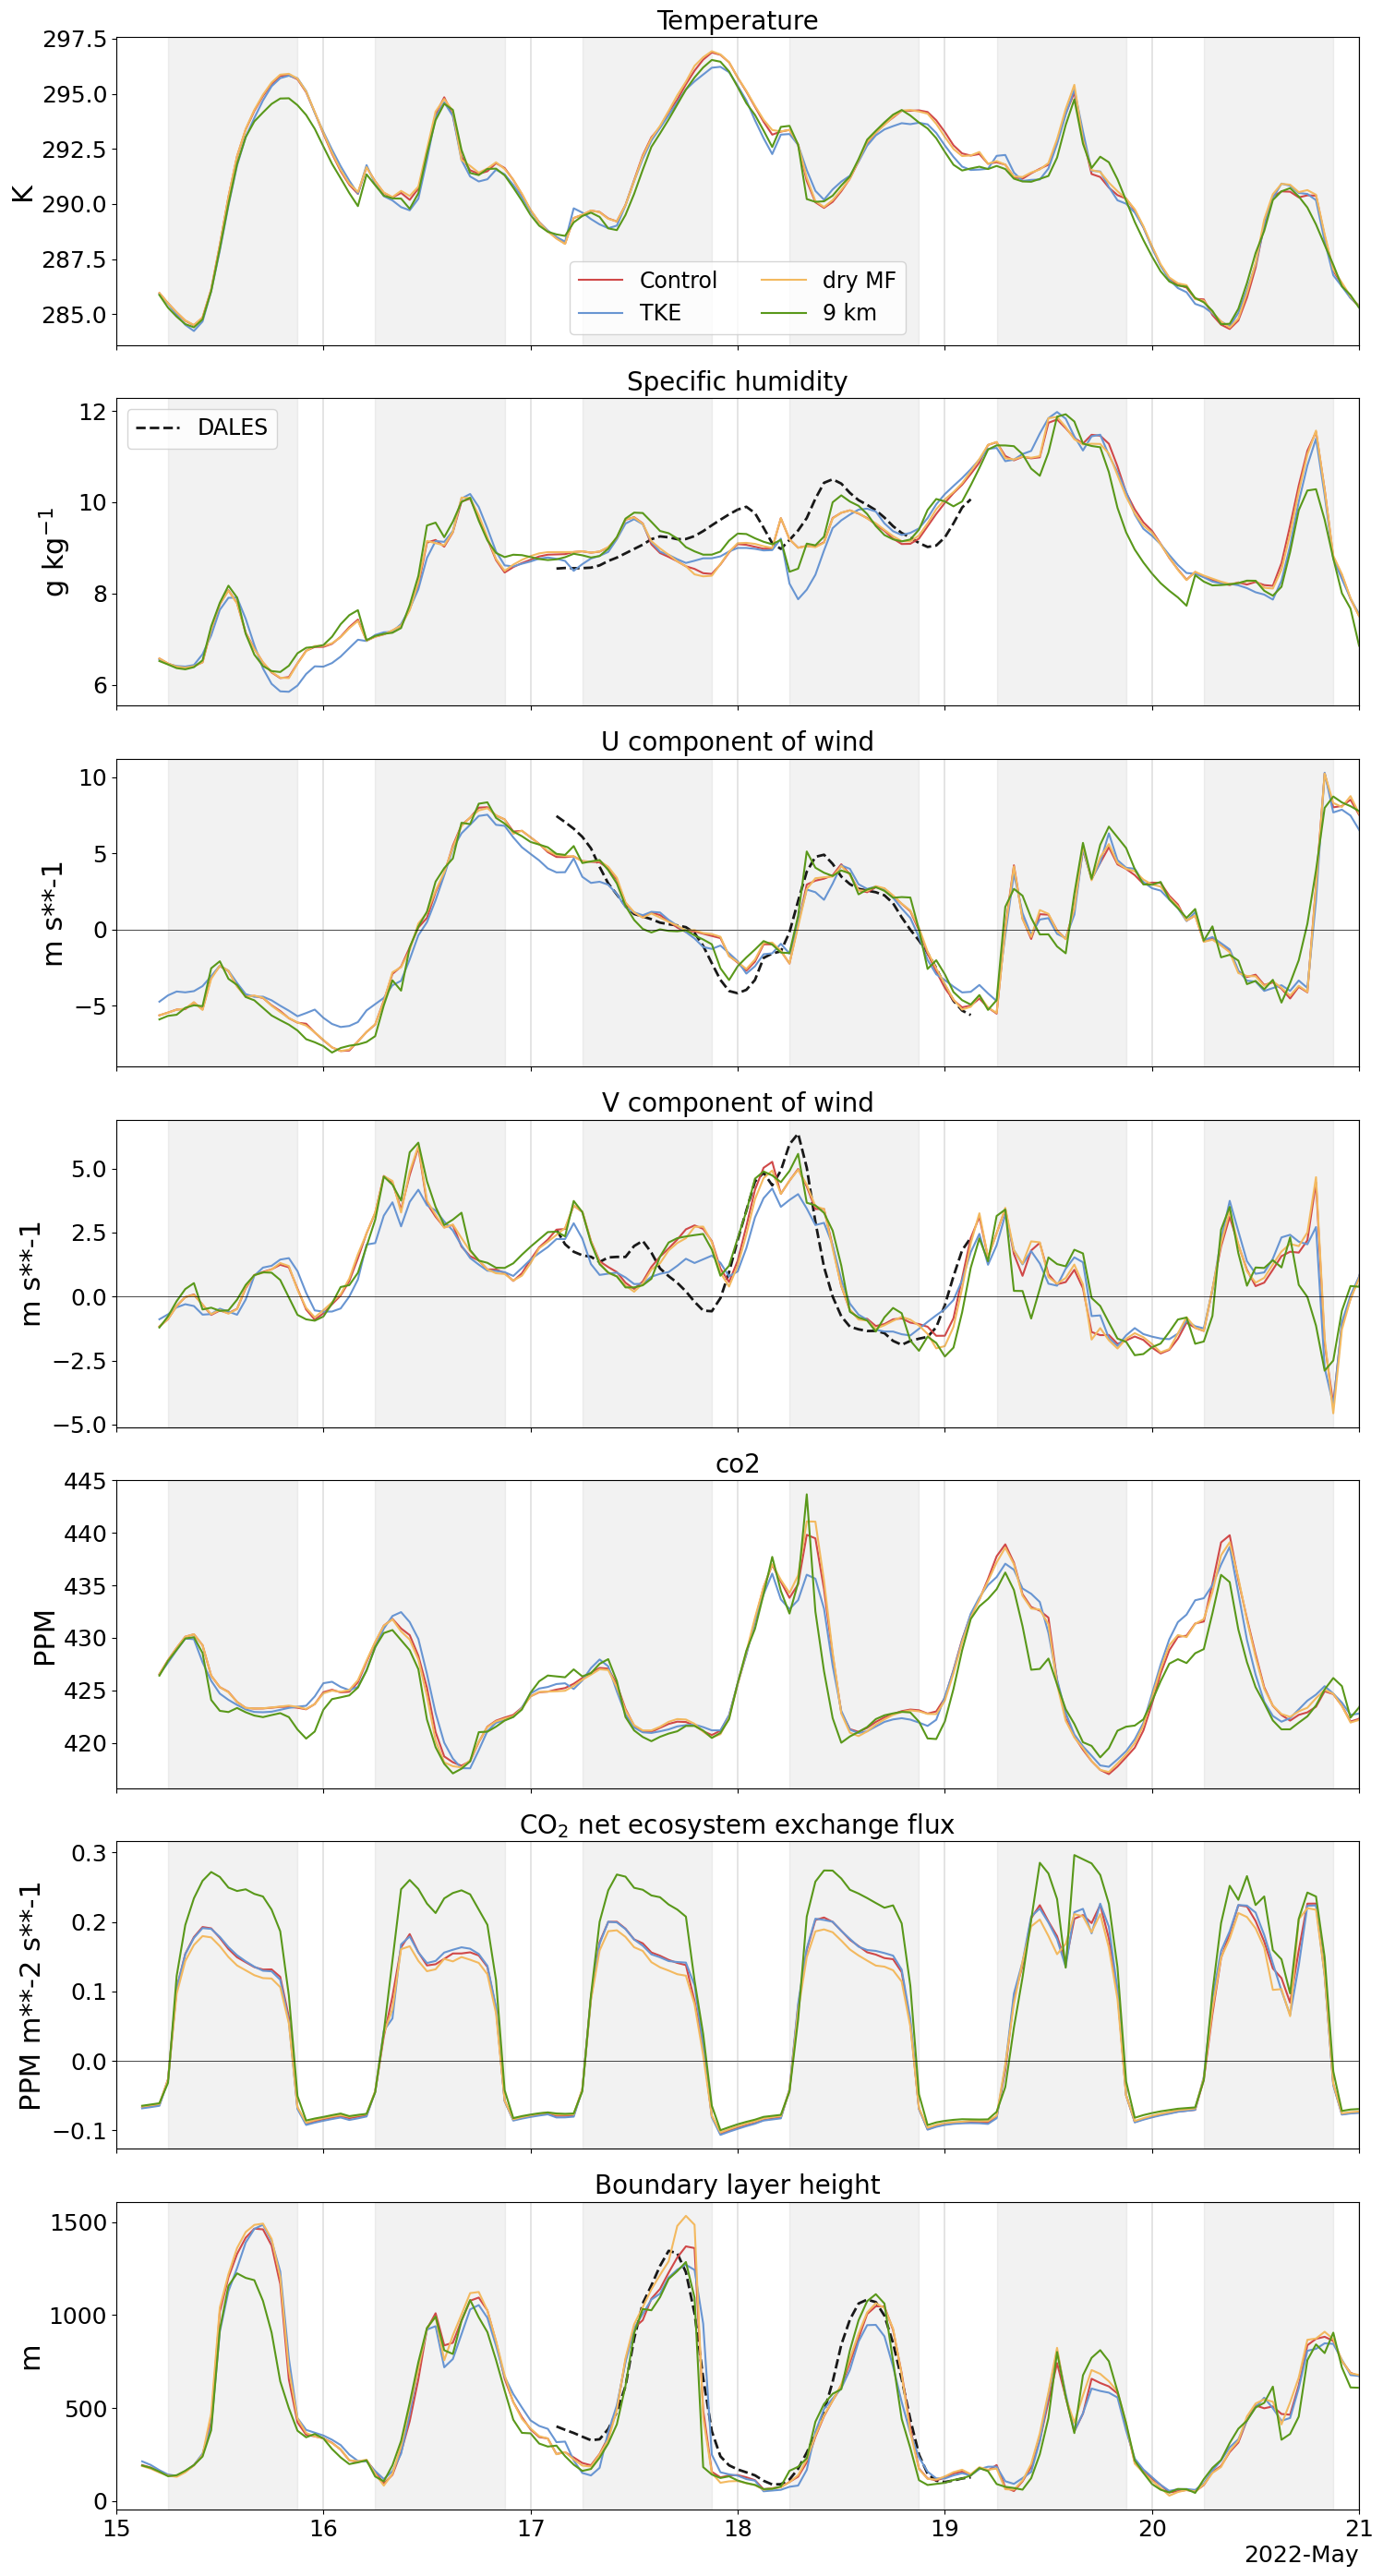

In [ ]:
#####  Evolution of Standard variables at 100m at Cabauw  #####
################################################################
# Include 'NEE' as the last variable
vars = ['t', 'q', 'u', 'v', 'co2', 'fco2nee','blh']
z =100 # m
fig, axes = plt.subplots(len(vars), 1, figsize=(15, 4 * len(vars)), sharex=True)

if len(vars) == 1:
    axes = [axes]

# Generate midnight ticks between t0 and t1
midnights = []
dt = t0.replace(hour=0, minute=0, second=0, microsecond=0)
while dt <= t1:
    midnights.append(dt)
    dt += timedelta(days=1)

# Loop over all variables
for i, (ax, var) in enumerate(zip(axes, vars)):
    
    if var =='q': 
        dales_var = 'qt'
        (dales_prof_hr[dales_var]*1000).sel(zt=z, method='nearest').plot(x='time', ax=ax,label='DALES',lw=2,ls='--',c='k',alpha=0.9)
    elif var in ['u','v']: 
        dales_var = var
        dales_prof_hr[dales_var].sel(zt=z, method='nearest').plot(x='time', ax=ax,label='DALES',lw=2,ls='--',c='k',alpha=0.9)
    # elif var == 'co2': 
    #     dales_var = 'sv004_ppm'
    #     dales_prof_hr[dales_var].sel(zt=z, method='nearest').plot(x='time', ax=ax,label='DALES',lw=2,ls='--',c='k',alpha=0.9)
    elif var == 'blh':
        dales_var = var
        dales_prof_hr[dales_var].plot(x='time', ax=ax,label='DALES',lw=2,ls='--',c='k',alpha=0.9)

    
    if var in ['fco2nee','blh']:
        # Surface dataset
        first_exp = exp_names[0][0]
        units = getattr(srf_fc_slab_dict[first_exp][var], 'units', '')
        var_long = getattr(srf_fc_slab_dict[first_exp][var], 'long_name', var)
        if var == 'fco2nee':
            var_long = f"CO$_2$ net ecosystem exchange flux"

        for ide,(exp, _, label) in enumerate(exp_names):
            s_slab = srf_fc_slab_dict[exp]
            s_slab[var].plot(x='time', ax=ax, label=label if i == 0 else None, c= col[ide])

    else:
        # 3D (height-dependent) dataset
        first_exp = exp_names[0][0]
        units = getattr(z_fc_slab_dict[first_exp][var], 'units', '')
        var_long = getattr(z_fc_slab_dict[first_exp][var], 'long_name', var)

        for ide,(exp, _, label) in enumerate(exp_names):
            z_slab = z_fc_slab_dict[exp].sel(height=z, method='nearest')
            z_slab[var].plot(x='time', ax=ax, label=label if i == 0 else None, c= col[ide])

    if var in ['u', 'v','fco2nee']:
        ax.axhline(0, color='black', linewidth=0.5)

    # Add vertical lines at midnight
    for dt in midnights:
        ax.axvline(dt, color='grey', linewidth=0.3, linestyle='-')

    # Add shaded region for daytime
    for dt in midnights:
        day_start = dt + timedelta(hours=daytime[0])
        day_end = dt + timedelta(hours=daytime[1])
        ax.axvspan(day_start, day_end, color='grey', alpha=0.1)

    ax.set_xlim(t0, t1)
    ax.set_xlabel('')
    ax.set_ylabel(units)
    ax.set_title(var_long, fontsize=20)

    if i in [0,1]:
        ax.legend(fontsize=17,ncol=2)

plt.tight_layout()


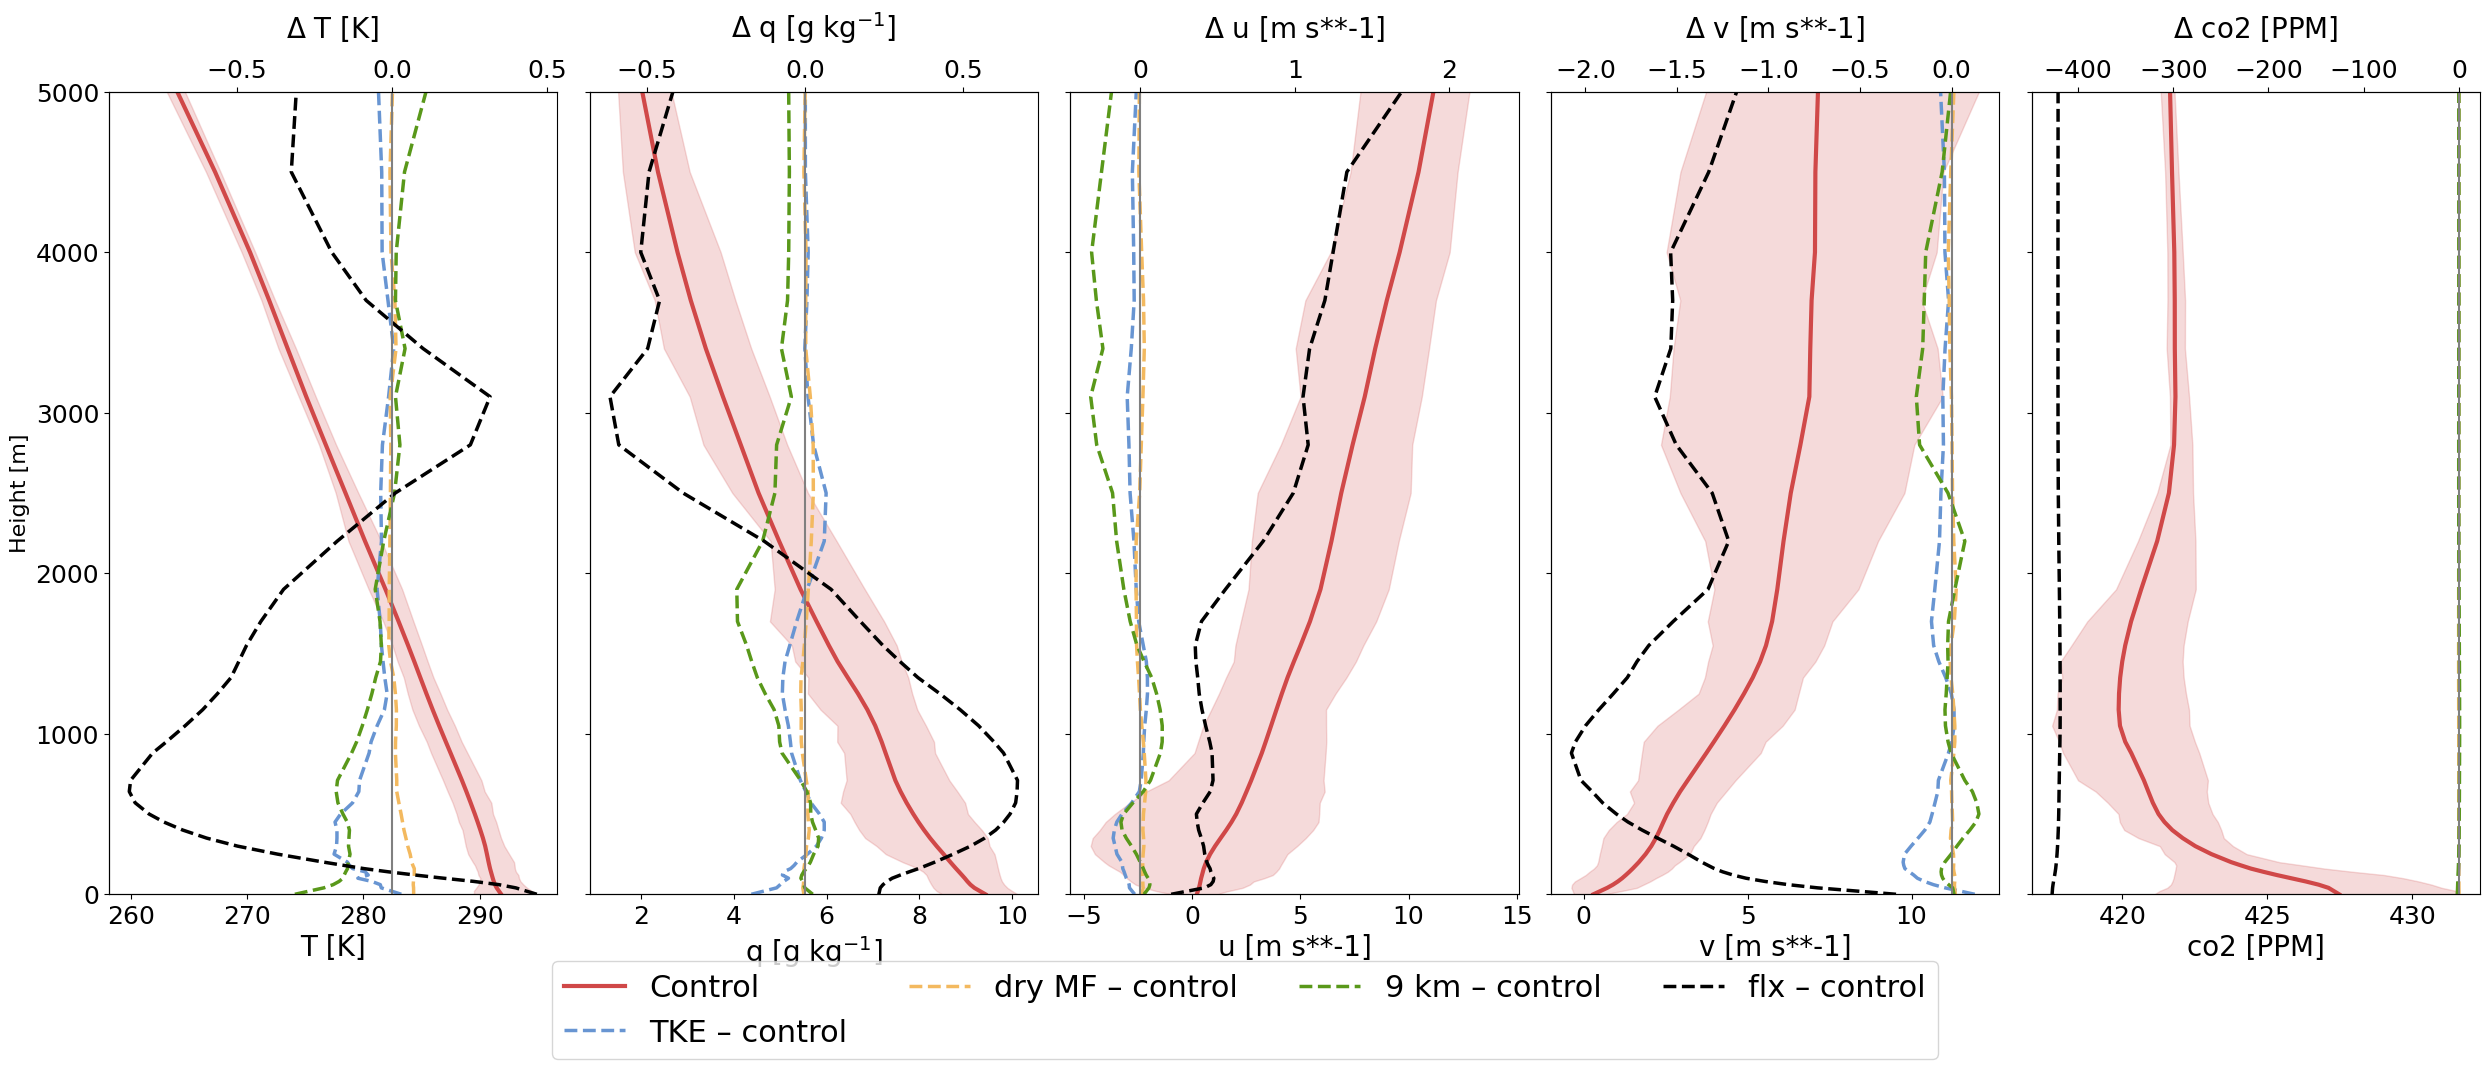

In [ ]:
# Variables
vars = ['t', 'q', 'u', 'v', 'co2']
fig, axes = plt.subplots(1, len(vars), figsize=(5 * len(vars), 10), sharey=True)

if len(vars) == 1:
    axes = [axes]

# Loop over variables
for i, (ax, var) in enumerate(zip(axes, vars)):
    ax2 = ax.twiny()  # Secondary x-axis for Δ profiles

    for ide, (exp, _, label) in enumerate(exp_names):
        z_slab = z_fc_slab_dict[exp]

        # Daytime mask
        hour = z_slab.time.dt.hour
        mask = (hour >= daytime[0]) & (hour <= daytime[1])
        day_data = z_slab[var].where(mask, drop=True)

        if ide == 0:
            # CONTROL: mean + IQR shading
            q25 = day_data.chunk({'time': -1}).quantile(0.25, dim='time')
            q75 = day_data.chunk({'time': -1}).quantile(0.75, dim='time')
            mean_profile = day_data.mean('time')
            ax.plot(mean_profile, mean_profile['height'], label=label, color=col[ide], lw=3)
            ax.fill_betweenx(mean_profile['height'], q25, q75, color=col[ide], alpha=0.2)
        else:
            # OTHER: Δ vs control on secondary x-axis
            ctrl_slab = z_fc_slab_dict[exp_names[0][0]]
            ctrl_day_data = ctrl_slab[var].where(ctrl_slab.time.dt.hour.isin(range(daytime[0], daytime[1] + 1)), drop=True)
            delta = (day_data - ctrl_day_data).mean('time')

            ax2.plot(delta, delta['height'], ls='--', lw=2.5, label=f"{label} – control", color=col[ide])

    # Label and axis formatting
    first_exp = exp_names[0][0]
    units = getattr(z_fc_slab_dict[first_exp][var], 'units', '')
    var_long = var
    if var =='t': var_long='T'

    ax.set_xlabel(f"{var_long} [{units}]", fontsize=20)
    # ax.set_title(var_long, fontsize=18)
    # ax.grid(True)

    if i == 0:
        ax.set_ylabel("Height [m]", fontsize=16)
        # Fix 2: combine legends from both axes
        handles_ax, labels_ax = ax.get_legend_handles_labels()
        handles_ax2, labels_ax2 = ax2.get_legend_handles_labels()
        fig.legend(handles_ax + handles_ax2, labels_ax + labels_ax2,
           loc='lower center', bbox_to_anchor=(0.5, -0.08),
           ncol=4, fontsize=22, frameon=True)
    else:
        ax.set_ylabel("")

    # Secondary axis formatting
    ax2.axvline(0, color='grey', lw=1.5)
    ax2.set_xlabel(r'$\Delta$ ' + var_long + f' [{units}]', fontsize=20, labelpad=15)
    ax2.spines['right'].set_visible(False)

    # Limits and range
    ax.set_ylim([0, 5000])
    

plt.tight_layout()
plt.subplots_adjust(bottom=0.1)  # Add space for the legend

In [ ]:
ens_times = srf_nemo_slab_dict[nemo_exp_names[1][0]]['time']
exp_times = srf_fc_slab_dict[exp]['time']
common_times = np.intersect1d(ens_times, exp_times)

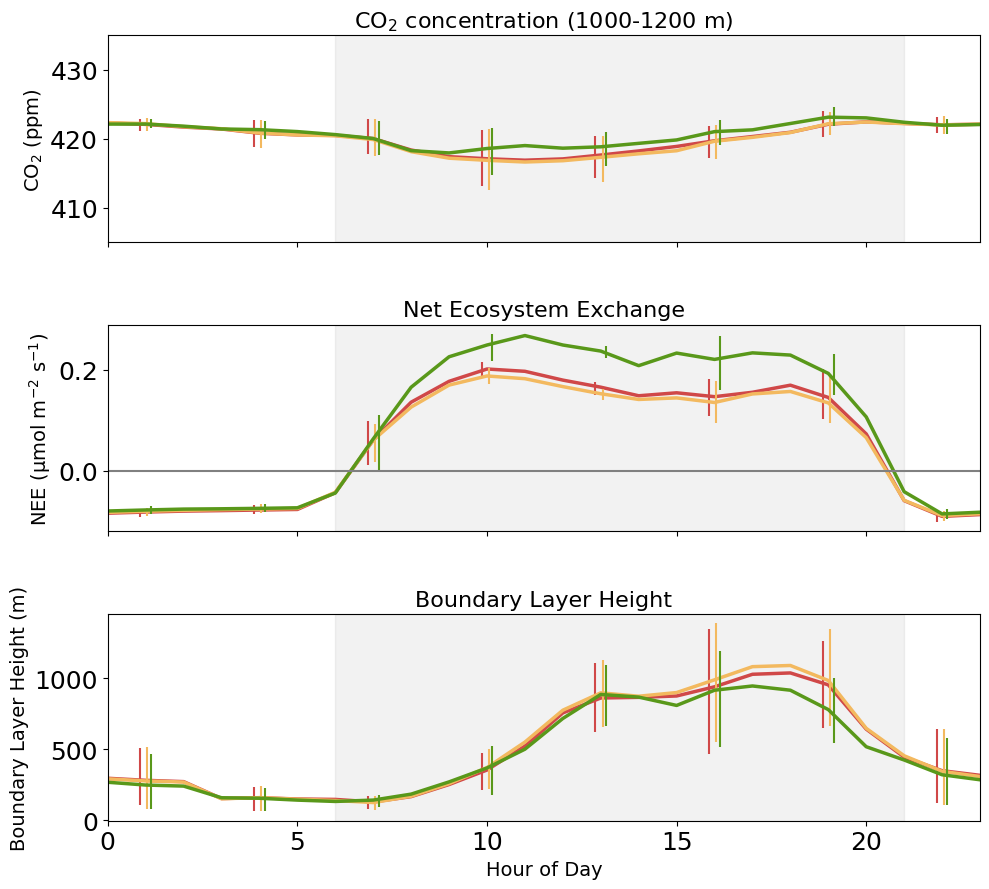

In [83]:
### Diurnal cycle of concentration, NEE, and BLH ###
###################################################
levels = [1000, 1200]  # For averaging concentration
highlight_exps=['ctrl','dryMF','ctrl_9km']

vars = ['co2', 'fco2nee', 'blh']
var_labels = ['CO$_2$ (ppm)', 'NEE (μmol m$^{-2}$ s$^{-1}$)', 'Boundary Layer Height (m)']
var_titles = [f'CO$_2$ concentration ({levels[0]}-{levels[1]} m)', 'Net Ecosystem Exchange', 'Boundary Layer Height']

fig, axes = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# Generate offsets evenly spaced around 0
num_exps = len(exp_names)
dx_step = 0.28 / max(num_exps - 1, 1)
offsets = [dx_step * (i - (num_exps - 1) / 2) for i in range(num_exps)]

for ax, var, label_y, title in zip(axes, vars, var_labels, var_titles):
    for (exp, _, label), c, dx in zip(exp_names, col[:num_exps], offsets):
        if var == 'co2':
            z_slab = z_fc_slab_dict[exp].sel(time=common_times).sel(height=slice(levels[0], levels[1])).mean('height')
            data = z_slab[var]
        else:
            data = srf_fc_slab_dict[exp][var]


        grouped = data.groupby('time.hour')
        diurnal = grouped.mean()
        p10 = grouped.quantile(0.10)
        p90 = grouped.quantile(0.90)

        if exp in highlight_exps:
            ax.plot(diurnal.hour, diurnal, label=label, color=c, lw=2.5)

            for hour in range(1, 24, 3):
                x = hour + dx
                ylow = p10.sel(hour=hour)
                yhigh = p90.sel(hour=hour)
                ax.vlines(x, ylow, yhigh, color=c, lw=1.5)

    ax.set_ylabel(label_y, fontsize=14)
    ax.set_title(title, fontsize=16)
    ax.set_xlim([0, 23])
    if var == 'fco2nee':
        ax.axhline(0, color='grey', lw=1.5)

    ax.axvspan(daytime[0], daytime[1], color='grey', alpha=0.1)

axes[-1].set_xlabel('Hour of Day', fontsize=14)
# axes[0].legend(fontsize=13, loc='upper right', ncol=1)

####
axes[0].set_ylim([405, 435])
####

plt.tight_layout()
plt.subplots_adjust(hspace=0.4)

# Experimental plots

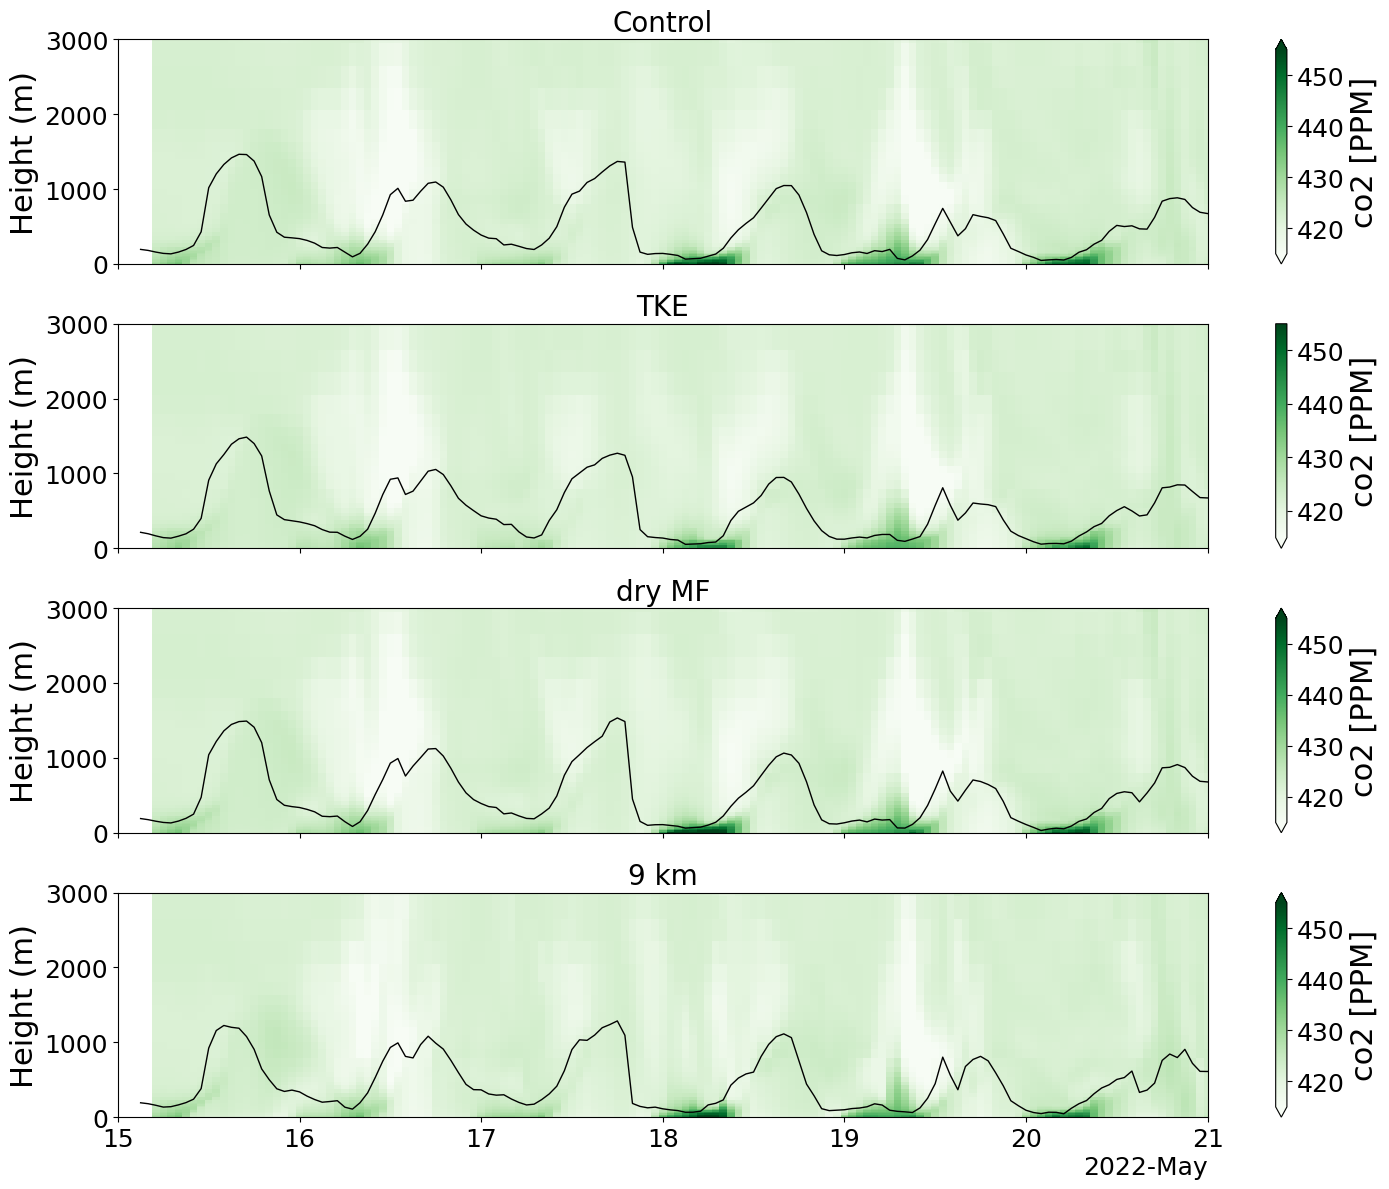

In [6]:
#####  Evolution of CO2 concentration for all experiments  #####
################################################################
# Create subplots: n rows, 1 column
fig, axes = plt.subplots(len(exp_names), 1, figsize=(15, 3 * len(exp_names)), sharex=True)

# If only one experiment, axes is not a list
if len(exp_names) == 1:
    axes = [axes]

# Loop through experiments
for ax, (exp,_,label) in zip(axes, exp_names):
    z_slab = z_fc_slab_dict[exp]
    srf_slab = srf_fc_slab_dict[exp]
    
    # Plot CO₂ profile
    z_slab['co2'].plot(y='height', cmap='Greens', vmin=415, vmax=455, ax=ax)
    
    # Overlay BLH
    srf_slab['blh'].plot(x='time', color='k', lw=1, ax=ax)
    
    ax.set_ylim(0, 3000)
    ax.set_xlim(t0, t1)
    ax.set_title(label,fontsize=20)
    ax.set_ylabel('Height (m)')
    ax.set_xlabel('')

plt.tight_layout()

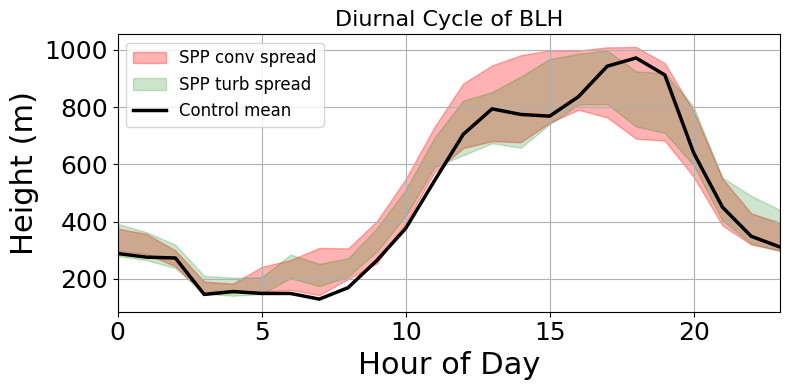

In [7]:
ens_times = srf_nemo_slab_dict[nemo_exp_names[1][0]]['time']
exp_times = srf_fc_slab_dict[exp]['time']
common_times = np.intersect1d(ens_times, exp_times)

plt.figure(figsize=(8, 4))

# 1️⃣ Plot shaded ensemble spreads
for i, (ens_key, _, ens_lab, ens_color) in enumerate(nemo_exp_names[1:-1]):
    min_member = srf_nemo_slab_dict[ens_key]['blh'].sel(time=common_times).min(dim='number')
    max_member = srf_nemo_slab_dict[ens_key]['blh'].sel(time=common_times).max(dim='number')

    min_by_hour = min_member.groupby('time.hour').mean('time')
    max_by_hour = max_member.groupby('time.hour').mean('time')

    plt.fill_between(
        min_by_hour['hour'].values,
        min_by_hour.values,
        max_by_hour.values,
        color=ens_color,
        alpha=max(0.05, 0.3 - 0.1 * i),
        label=f'{ens_lab} spread'
    )

# 2️⃣ Overlay mean lines and quantile bars for selected experiments
# Adjust the list to only include experiments you want to highlight
highlight_exps = ['ctrl',]  # replace with your experiment names
dx = 0.18  # x-axis offsets for vertical quantiles

for ie, (exp, _, label) in enumerate(exp_names):
    if exp in highlight_exps:
        srf_slab = srf_fc_slab_dict[exp].sel(time=common_times)
        grouped = srf_slab['blh'].groupby('time.hour')
        diurnal = grouped.mean()
        p10 = grouped.quantile(0.10)
        p90 = grouped.quantile(0.90)

        # Mean line
        # plt.plot(diurnal.hour, diurnal, label=f'{label} mean', color=col[exp_names.index((exp, _, label))], lw=2.5)
        plt.plot(diurnal.hour, diurnal, label=f'{label} mean', color='k', lw=2.5)

        # Vertical quantile lines every 3 hours
        for hour in range(1, 24, 3):
            x = hour + dx*ie
            ylow = p10.sel(hour=hour)
            yhigh = p90.sel(hour=hour)
            # plt.vlines(x, ylow, yhigh, color=col[exp_names.index((exp, _, label))], lw=1.5)

plt.xlim([0, 23])
plt.xlabel('Hour of Day')
plt.ylabel('Height (m)')
plt.title('Diurnal Cycle of BLH', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()


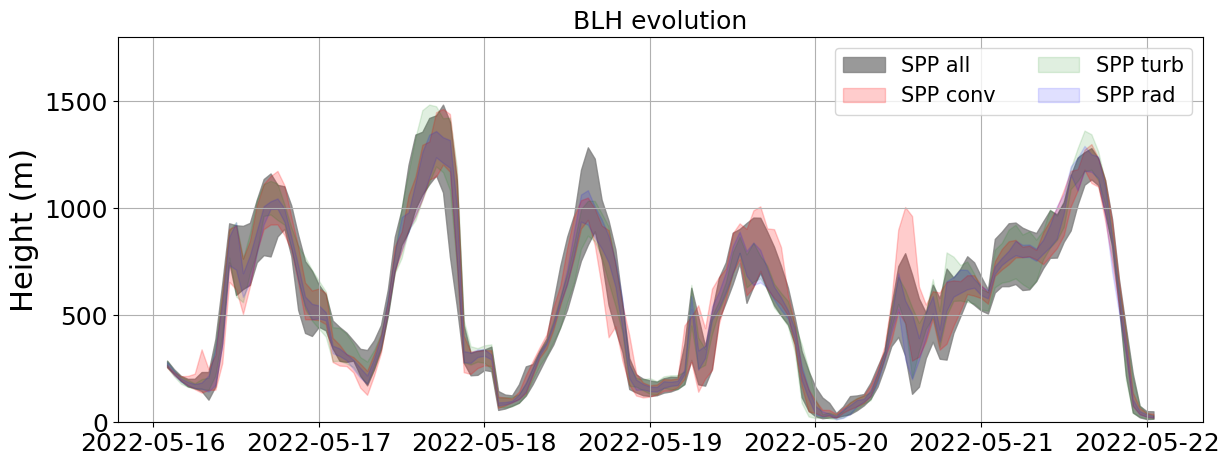

In [51]:
### evolution of the BLH
# Set up the figure
fig, ax = plt.subplots(figsize=(14, 5))

# Plot shaded regions for ensemble runs
for i, (ens_key,_,ens_lab, ens_color) in enumerate(nemo_exp_names):
    # # Plot all lines in grey
    # for number in srf_nemo_slab_dict[ens_key]['number']:
    #     srf_nemo_slab_dict[ens_key]['blh'].sel(number=number).plot(x='time', color=ens_color, alpha=0.5, linewidth=0.8, ax=ax)

    blh_min = srf_nemo_slab_dict[ens_key]['blh'].min(dim='number')
    blh_max = srf_nemo_slab_dict[ens_key]['blh'].max(dim='number')
    
    ax.fill_between(
        srf_nemo_slab_dict[ens_key]['time'].values,
        blh_min.values,
        blh_max.values,
        color=ens_color,
        alpha=max(0.12, 0.8 - 0.6 * i),
        label=ens_lab
    )

# for (exp,_, label), c in zip(exp_names, col):
#     srf_slab = srf_fc_slab_dict[exp]
#     # Plot mean line
#     srf_slab['blh'].plot(label=label, color=c, lw=2,alpha=0.9)

ax.set_title('BLH evolution',fontsize=18)
ax.set_ylabel('Height (m)')
ax.set_xlabel('')
ax.set_ylim([0,1800])
ax.legend(fontsize=15,ncol=2)
plt.grid(True)
# ax.set_xlim(t0, t1)

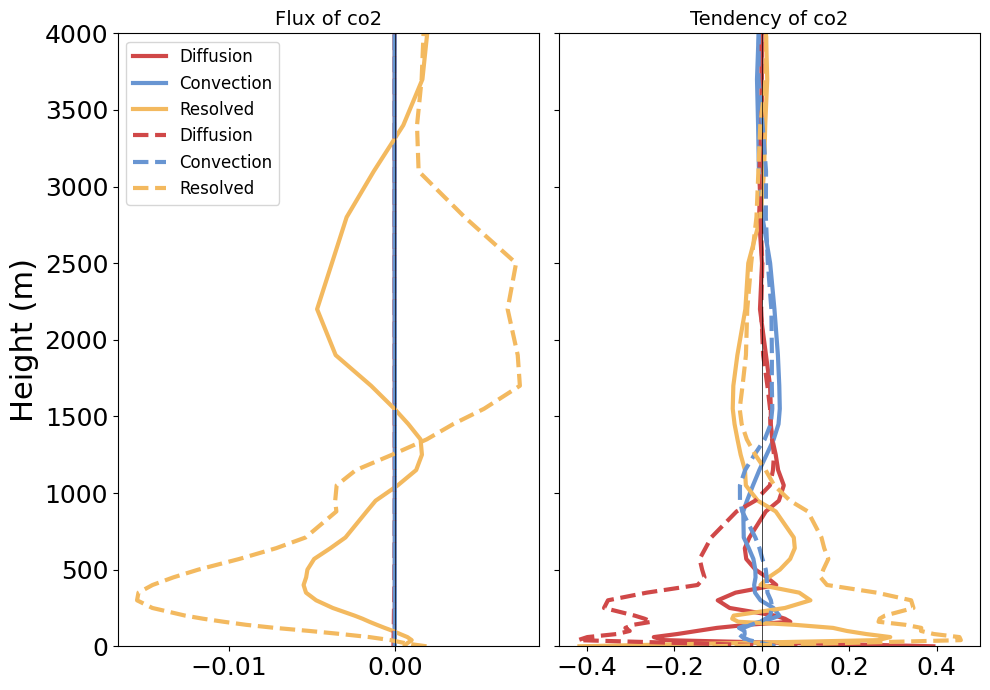

In [16]:
var = 'co2'
fig, axs = plt.subplots(1, 2, figsize=(10, 7), sharey=True)
for ide, exp in enumerate(['ctrl','ctrl_9km']):
    # --- Left panel: Flux ---
    ax = axs[0]
    z_fc_slab_dict[exp][var+'_flx_diff'].mean('time').plot(
        y='height', ax=ax, lw=3, label='Diffusion',c=col[0],ls=['-','--'][ide])
    z_fc_slab_dict[exp][var+'_flx_conv'].mean('time').plot(
        y='height', ax=ax, lw=3, label='Convection',c=col[1],ls=['-','--'][ide])
    filtered_ds[exp][var+'_flx_res'].mean(['latitude', 'longitude']).mean('time').plot(
        y='height', ax=ax, lw=3, label='Resolved',c=col[2],ls=['-','--'][ide])

    # --- Right panel: Tendency ---
    ax = axs[1]
    z_fc_slab_dict[exp][f'd{var}dt_diff'].mean('time').plot(
        y='height', ax=ax, label='Diffusion', c=col[0], lw=3,ls=['-','--'][ide])
    z_fc_slab_dict[exp][f'd{var}dt_conv'].mean('time').plot(
        y='height', ax=ax, label='Convection', c=col[1], lw=3,ls=['-','--'][ide])
    z_fc_slab_dict[exp][f'd{var}dt_dyn'].mean('time').plot(
        y='height', ax=ax, label='Resolved', c=col[2], lw=3,ls=['-','--'][ide])


for ax in axs: 
    ax.axvline(0, c='k', lw=0.5)
    ax.set_ylim([0, 4000])
    ax.set_xlabel('')

axs[0].set_title("Flux of " + var, fontsize=14)
axs[0].legend()
axs[0].set_ylabel('Height (m)')
axs[1].set_title("Tendency of " + var, fontsize=14)
axs[1].set_ylabel('')

plt.tight_layout()
plt.show()

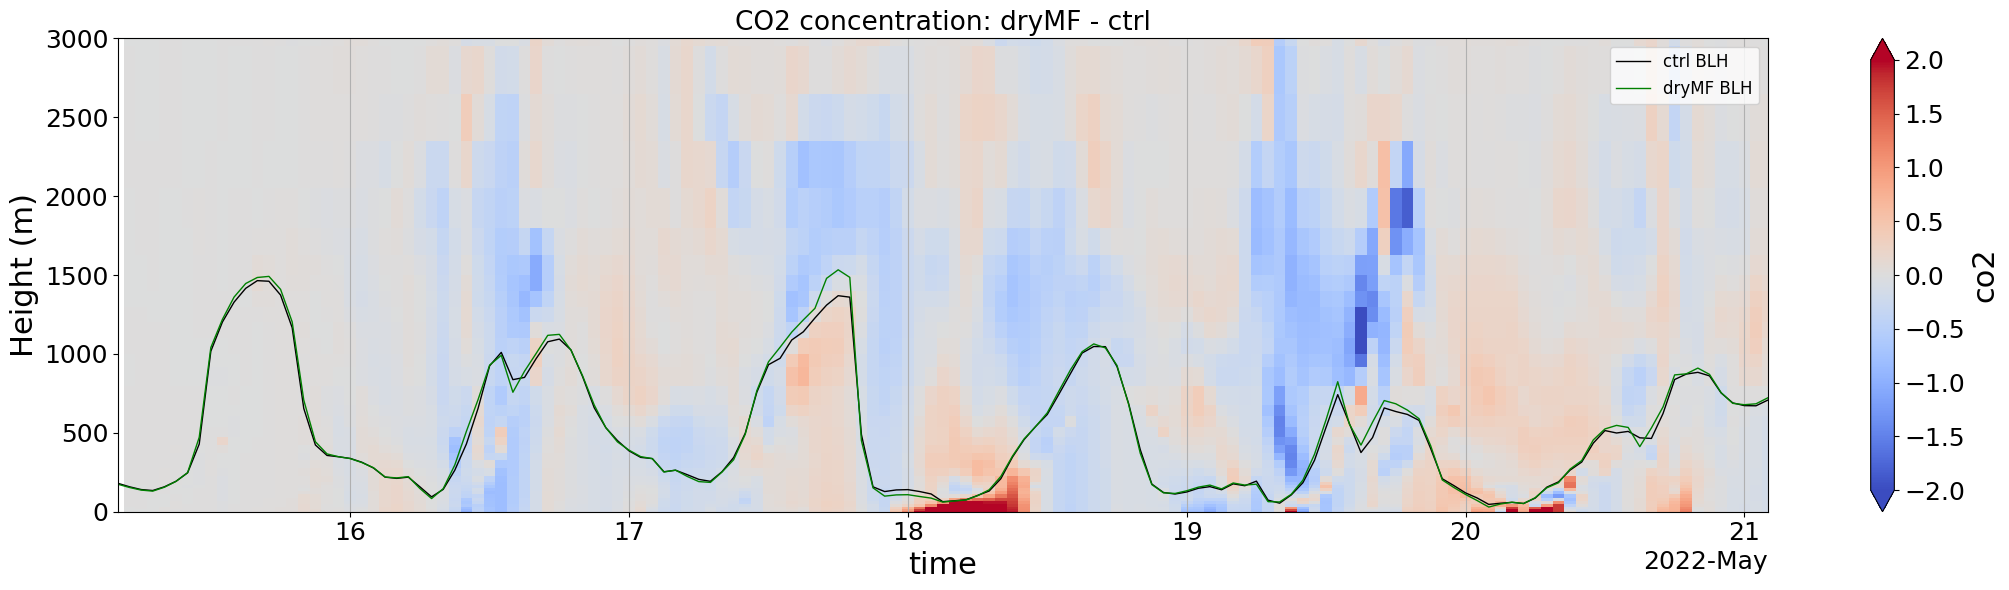

In [47]:
#####   Difference between experiments  #####
##############################################
# Time limits
str_time = '2022-05-15T04:00'
end_time = '2022-05-21T02:00'

# Experiments to compare
exp1 = 'dryMF'
exp2 = 'ctrl'

# Variables to plot: (variable_name, plot title)
vars_to_plot = [
    # ('dco2dt_dyn',  'CO2 tendency from dynamics'),
    # ('dco2dt_conv', 'CO2 tendency from convection'),
    # ('dco2dt_diff', 'CO2 tendency from diffusion'),
    ('co2', 'CO2 concentration'),
]

# Colormap limits (set to None for automatic scaling)
vmin = -2
vmax = 2

# Create a figure with rows equal to number of variables
fig, axes = plt.subplots(nrows=len(vars_to_plot), ncols=1, figsize=(22, len(vars_to_plot)*4+2), sharex=True)

# Make sure axes is always iterable
if len(vars_to_plot) == 1:
    axes = [axes]

# Loop through each variable
for ax, (var, title) in zip(axes, vars_to_plot):
    # Calculate difference between experiments
    data_diff = z_fc_slab_dict[exp1][var] - z_fc_slab_dict[exp2][var]

    # Plot the difference
    data_diff.plot(
        ax=ax,
        y='height',
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax
    )

    # Add boundary layer height lines for both experiments
    srf_fc_slab_dict[exp2]['blh'].plot(ax=ax, x='time', c='k', lw=1, label=f'{exp2} BLH')
    srf_fc_slab_dict[exp1]['blh'].plot(ax=ax, x='time', c='g', lw=1, label=f'{exp1} BLH')

    # Formatting
    ax.set_ylim(0, 3000)
    ax.set_xlim(
        datetime.datetime.strptime(str_time, "%Y-%m-%dT%H:%M"),
        datetime.datetime.strptime(end_time, "%Y-%m-%dT%H:%M")
    )
    ax.set_ylabel('Height (m)')
    ax.set_title(f'{title}: {exp1} - {exp2}', fontsize=19)
    ax.legend()
    ax.grid(axis='x')

# Adjust layout for readability
plt.tight_layout()


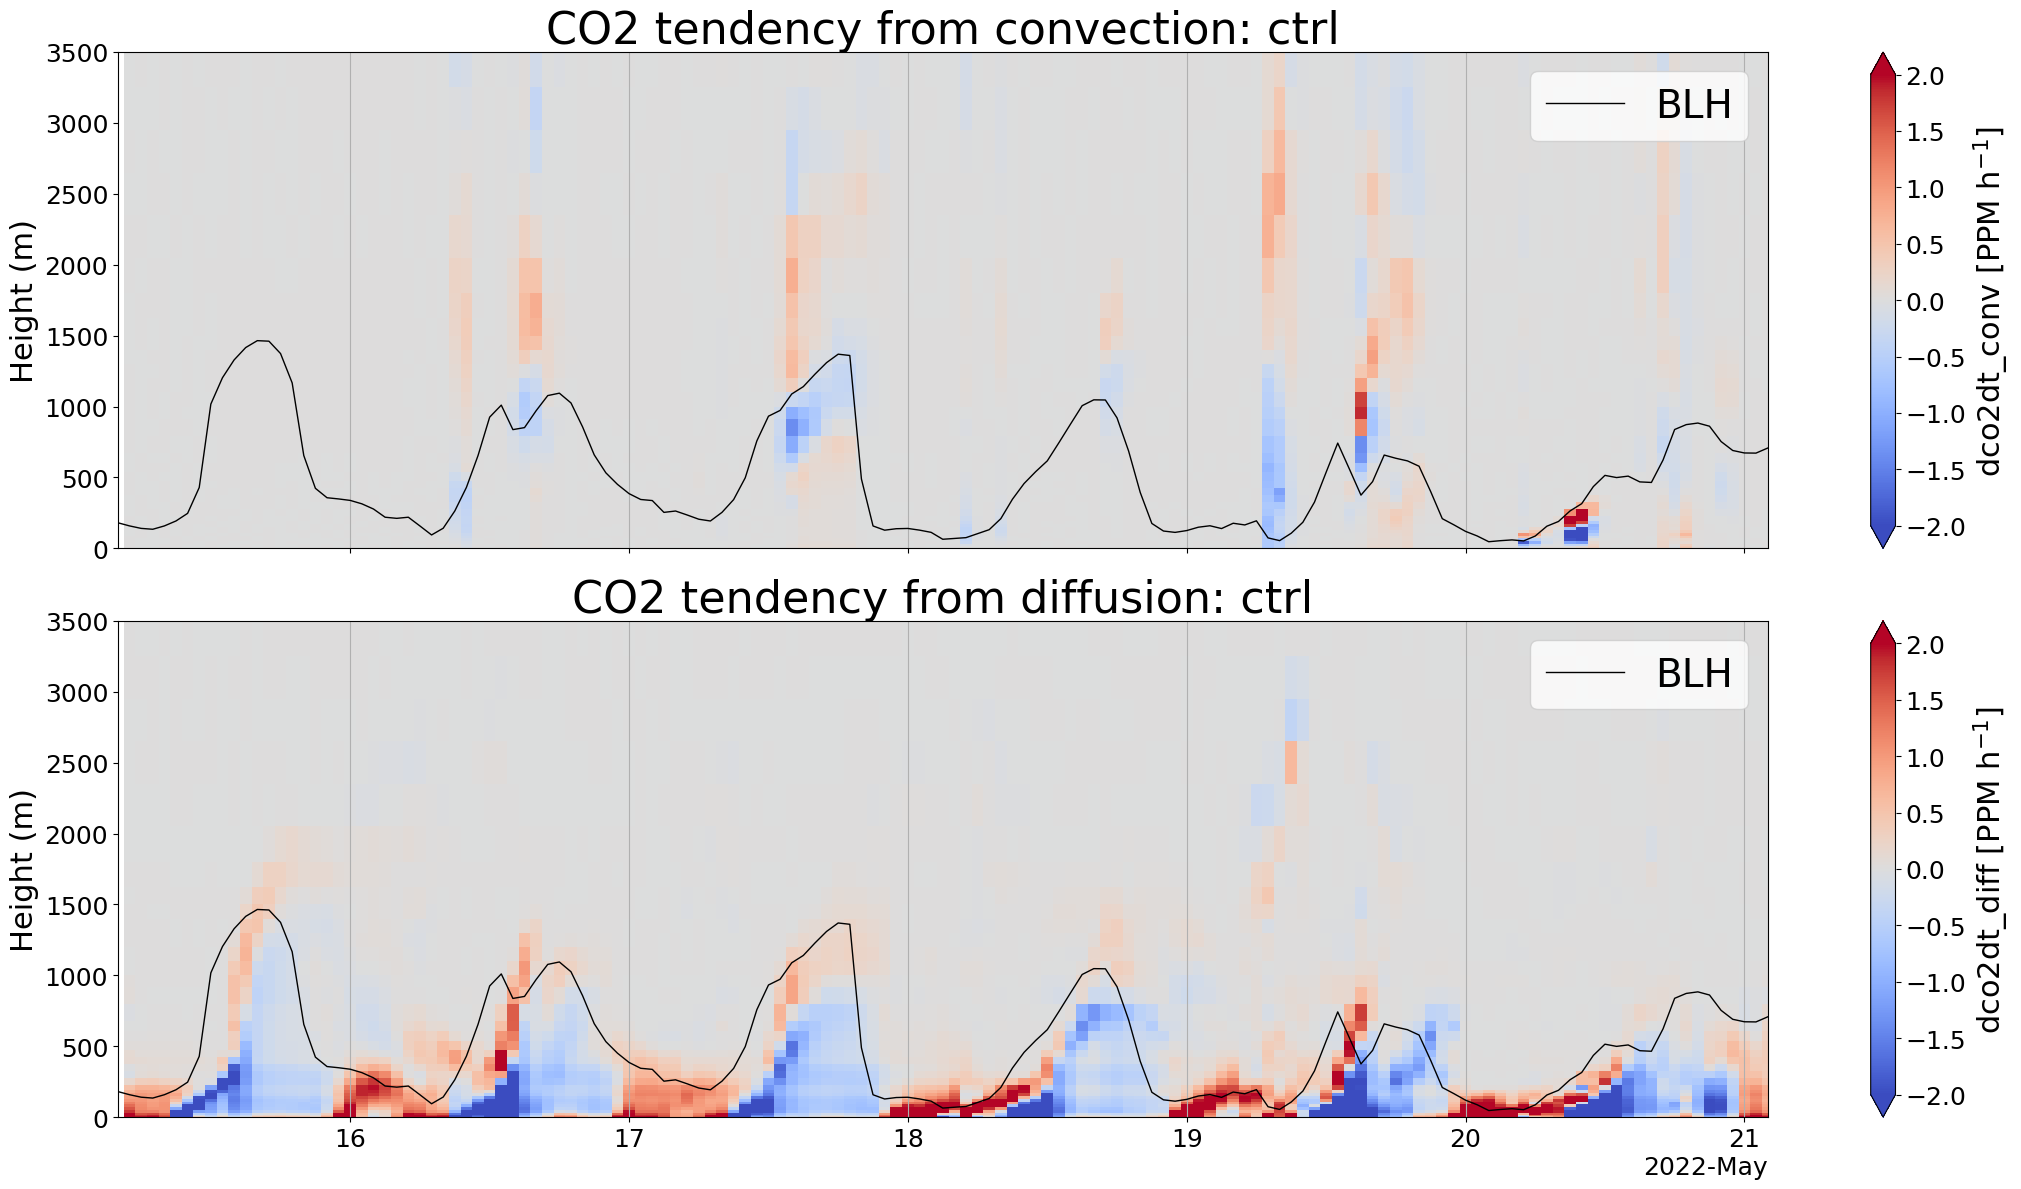

In [49]:
#####   Evolution of CO2 tendency terms for one experiment  #####
#####################################################################
# Time limits
str_time = '2022-05-15T04:00'
end_time = '2022-05-21T02:00'

# Experiment name
exp = 'ctrl'

# Variables to plot
vars_to_plot = [
    # ('dco2dt_dyn',  'CO2 tendency from dynamics'),
    ('dco2dt_conv', 'CO2 tendency from convection'),
    ('dco2dt_diff', 'CO2 tendency from diffusion'),
    # ('co2', 'CO2 concentration'),   
]

# Colormap limits (set to None for automatic scaling)
vmin = -2
vmax = +2

# Create a figure with 3 rows and 1 column
fig, axes = plt.subplots(nrows=len(vars_to_plot), ncols=1, figsize=(22, 12), sharex=True)

# Ensure axes is iterable even if only one variable
if len(vars_to_plot) == 1:
    axes = [axes]

# Loop through variables to plot
for ax, (var, title) in zip(axes, vars_to_plot):
    # Plot the variable
    (z_fc_slab_dict[exp][var]).plot(
        ax=ax,
        y='height',
        cmap='coolwarm',
        vmin=vmin,
        vmax=vmax
    )

    # Add boundary layer height lines
    srf_fc_slab_dict[exp]['blh'].plot(ax=ax, x='time', c='k', lw=1, label=f'BLH')

    # Set limits and labels
    ax.set_ylim(0, 3500)
    ax.set_xlim(
        datetime.datetime.strptime(str_time, "%Y-%m-%dT%H:%M"),
        datetime.datetime.strptime(end_time, "%Y-%m-%dT%H:%M")
    )
    ax.set_ylabel('Height (m)')
    ax.set_xlabel('')
    ax.set_title(f'{title}: {exp}', fontsize=32)
    ax.legend(fontsize=28)
    ax.grid(axis='x')

# Adjust layout for readability
plt.tight_layout()
plt.show()

(np.float64(19127.0), np.float64(19133.0))

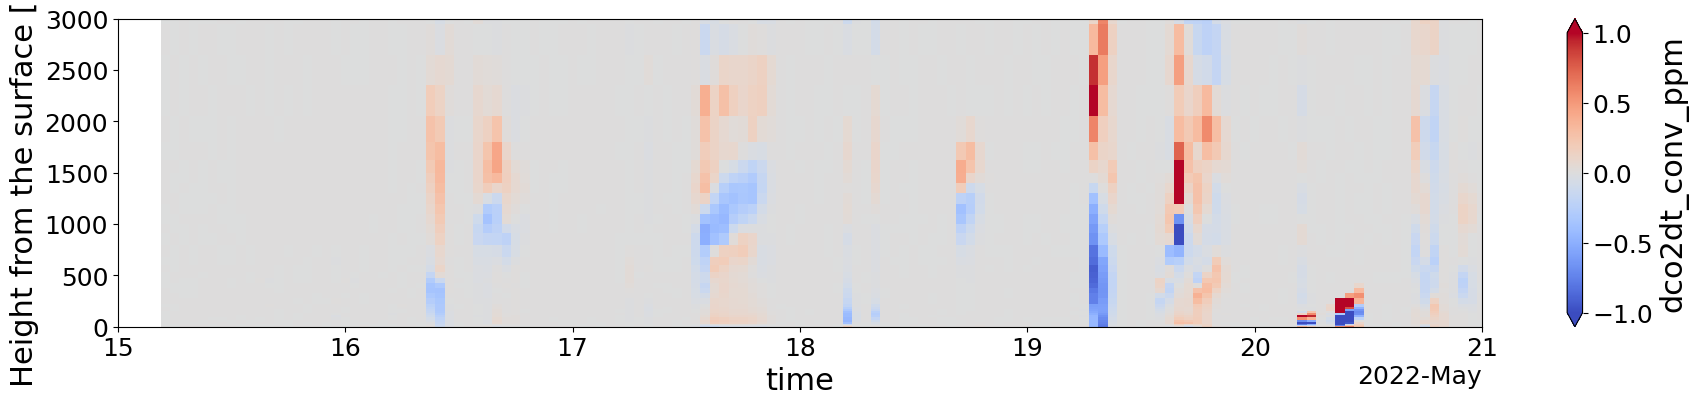

In [38]:
var = 'dco2dt_conv_ppm' #co2_ppm
plt.figure(figsize=(22,4))
dryMF_z_slab[var].plot( y='height',
                               cmap='coolwarm',
                # vmin=415, vmax=455
                vmin =-1
                )
# dryMF_srf_slab['blh'].plot(x='time',c='k',lw=1)
plt.ylim((0,3000))
plt.xlim((datetime.datetime.strptime(str_time, "%Y-%m-%d"),datetime.datetime.strptime(end_time, "%Y-%m-%d")))

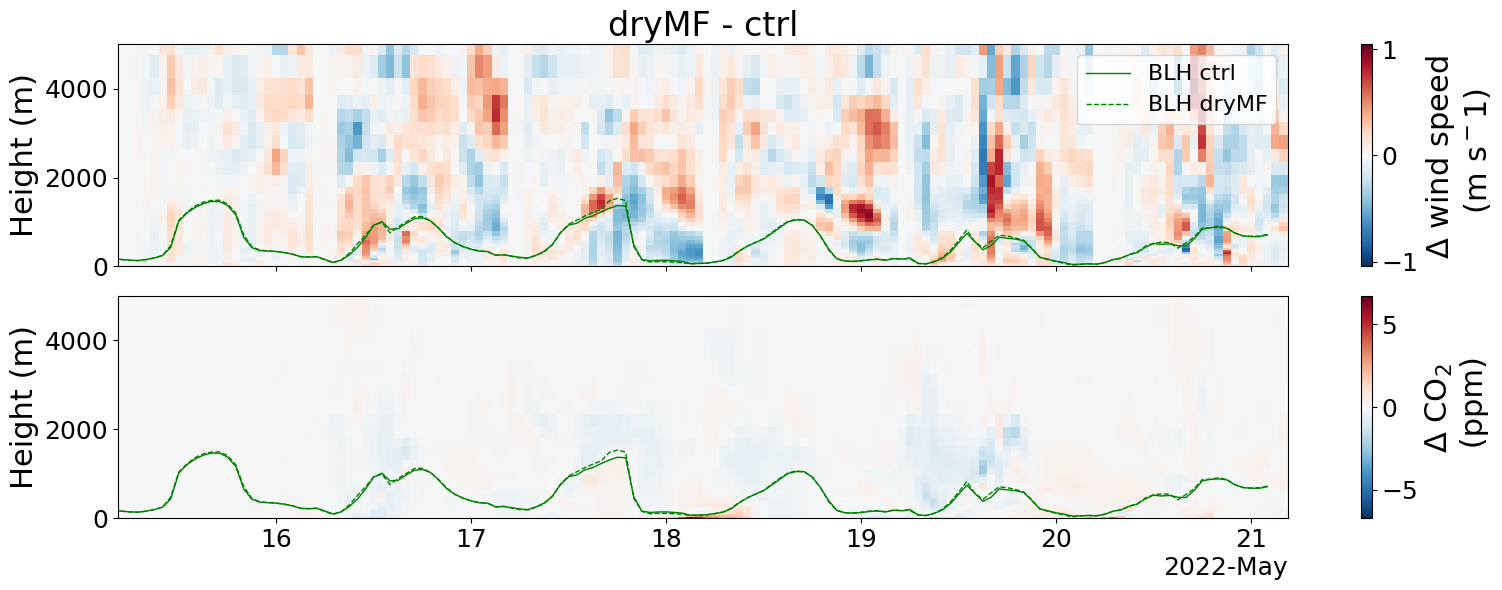

In [25]:
# difference betweeen experiments
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(16, 6), sharex=True)
for idx, var in enumerate(['wspd','co2_ppm']):
    units = tke_off_z_slab[var].attrs.get('units', '')  # Use empty string if 'units' is not set

    # Determine global min and max values for the colour scale
    vmin = min(tke_off_z_slab[var].min() for exp in exp_names).values
    vmax = max(tke_off_z_slab[var].max() for exp in exp_names).values
    # Compute the difference between the two experiments
    diff = dryMF_z_slab[var] - tke_off_z_slab[var]

    if var == 'co2_ppm':
        diff.plot(ax=axes[idx], x='time', cmap='RdBu_r',
            cbar_kwargs={'label': f'$\Delta$ CO$_2$ \n ({units.lower()})'})
    else:
        diff.plot(ax=axes[idx], x='time', cmap='RdBu_r',
            cbar_kwargs={'label': f'$\Delta$ wind speed \n (m s$^{-1}$)'})
    # Plot BL height
    tke_off_srf_slab['blh'].plot(ax=axes[idx],x='time', c='g', lw=1,label='BLH ctrl')
    dryMF_srf_slab['blh'].plot(  ax=axes[idx],x='time', c='g', lw=1,label='BLH dryMF',ls="--")


# Add vertical lines to all subplots
for ax in axes:
    ax.set_ylim([0,5000])
    ax.set_ylabel('Height (m)')
    ax.set_xlabel('')
    # for i in range(21, len(time_values), 24):  # Start from 23, step by 24
    #     ax.axvline(time_values[i], color='grey', lw=0.5)
axes[0].set_title(f'dryMF - ctrl',fontsize=24)
axes[0].legend(fontsize =16)
# Improve layout
plt.tight_layout()

# Third SPP